In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations


In [4]:
def plot_bars_with_sem3_test(groups, labels=None, ylabel="Value", figsize=(3,6),
                       bar_color="lightgray", dot_color="black", spine_width=2):
    """
    Plot multiple groups as bars with SEM and overlay individual data points.

    Parameters
    ----------
    groups : list of array-like
        List of numeric arrays/lists, one per group.
    labels : list of str, optional
        Labels for each group (x-axis).
    ylabel : str, optional
        Label for y-axis.
    figsize : tuple, optional
        (width, height) of the figure in inches.
    bar_color : str, optional
        Color of the bars.
    dot_color : str, optional
        Color of the overlaid dots.
    spine_width : float, optional
        Thickness of the axis spines.
    """

    groups = [np.asarray(g) for g in groups]
    n_groups = len(groups)

    # Allow single color or list of colors
    if isinstance(bar_color, (list, tuple, np.ndarray)):
        if len(bar_color) != n_groups:
            raise ValueError("Length of bar_color must match number of groups")
        bar_colors = bar_color
    else:
        bar_colors = [bar_color] * n_groups

    print(bar_colors)

    means = [np.nanmean(g) for g in groups]
    sems  = [np.nanstd(g, ddof=1) / np.sqrt(np.sum(~np.isnan(g))) for g in groups]


    if labels is None:
        labels = [f"Group {i+1}" for i in range(n_groups)]
    for i,lbl in enumerate(labels):
        print(f"group: {lbl}, mean: {means[i]}, sem: {sems[i]}")

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(n_groups)

    # Bars + SEM
    ax.bar(x, means, yerr=sems, capsize=8,
           color=bar_colors, edgecolor="black", linewidth=1.5)

    # Overlay dots
    for i, vals in enumerate(groups):
        # jitter = (np.random.rand(len(vals)) - 0.5) * 0.2
        jitter = 0
        ax.scatter(np.full(len(vals), x[i]) + jitter, vals,
                   color=dot_color, s=40, alpha=0.8, zorder=3)

    # Axis labels & limits
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)

    # --- Style adjustments ---
    # Thicker left & bottom spines, remove top/right
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(spine_width)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Ticks only on left/bottom
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")

    # Add baseline at y = 0
    ax.axhline(0, color="black", linewidth=1.2)

    plt.tight_layout()
    return ax

def add_sig_bar(ax, x1, x2, y, h, text, fontsize=16):
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=1.5, color="black")
    ax.text((x1+x2)/2, y+h, text,
            ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold")

In [5]:
def shapiro_wilk(list_arrays, list_labels, alpha=0.05):
  for name, group in zip(list_labels, list_arrays):
    stat, p = shapiro(group)

    print(f"{name}")
    print(f"  W statistic = {stat:.4f}")
    print(f"  p-value     = {p:.4f}")

    if p > 0.05:
        print("  → Data look approximately normal\n")
        pass_normality = True
    else:
        print("  → Significant deviation from normality\n")
        pass_normality = False

  return pass_normality


def levene_and_brown_forsythe_test(list_arrays, test2run=0):
  test = [["Brown-Forsythe test", "median"], ["Levene's test", "mean"]]

  pass_similar_var = False
  if test2run < 2:
    test = [test[test2run]]


  for i in range(len(test)):
    stat, p_val = levene(*list_arrays, center=test[i][1])
    print(f'{test[i][0]}')
    print(f"Statistic = {stat:.4f}")
    print(f"p-value   = {p_val:.4f}")

    if p_val > 0.05:
      print("→ Variances are not significantly different\n")
      if test2run < 2:
        pass_similar_var = True

    else:
      print("→ Variances differ significantly\n")

  return pass_similar_var


def anova_test(list_arrays):
  f_stat, p_value = f_oneway(*list_arrays)

  print("One-way ANOVA")
  print(f"F statistic = {f_stat:.4f}")
  print(f"p-value     = {p_value:.4f}")

  if p_value < 0.05:
      print("→ Significant differences exist between groups\n")
      pass_anova = True
  else:
      print("→ No significant differences detected\n")
      pass_anova = False
  return pass_anova


def ETA_SQUARED(list_arrays):
  # Flatten data
  all_data = np.concatenate(list_arrays)

  # Grand mean
  grand_mean = np.mean(all_data)

  # Between-group sum of squares
  ss_between = sum(
      len(group) * (np.mean(group) - grand_mean)**2
      for group in list_arrays
  )

  # Total sum of squares
  ss_total = sum(
      (x - grand_mean)**2
      for x in all_data
  )

  # Eta squared
  eta_squared = ss_between / ss_total

  print("\nEffect size")
  print(f"Eta squared (η²) = {eta_squared:.4f}")


  # Interpretation guideline
  if eta_squared < 0.01:
      interpretation = "very small"
  elif eta_squared < 0.06:
      interpretation = "small"
  elif eta_squared < 0.14:
      interpretation = "medium"
  else:
      interpretation = "large"

  print(f"Effect size interpretation: {interpretation}")


def tukey_test(list_arrays, list_labels):

  # Flatten all values into one array
  all_data = np.concatenate(list_arrays)

  # Create matching labels
  labels = np.concatenate([
      np.repeat(name, len(group))
      for name, group in zip(list_labels, list_arrays)
  ])

  # Run Tukey HSD
  tukey = pairwise_tukeyhsd(
      endog=all_data,
      groups=labels,
      alpha=0.05
  )

  print(tukey)


def cohens_d(x, y):
  nx = len(x)
  ny = len(y)

    # pooled standard deviation
  pooled_sd = np.sqrt(
      ((nx - 1) * np.var(x, ddof=1) +
        (ny - 1) * np.var(y, ddof=1))
      / (nx + ny - 2)
  )

  d = (np.mean(x) - np.mean(y)) / pooled_sd
  return d


  print("\nCohen's d pairwise comparisons")


def cohens_all(list_arrays, list_labels):
  for (i, g1), (j, g2) in combinations(enumerate(list_arrays), 2):

    d = cohens_d(g1, g2)

    print(f"{list_labels[i]} vs {list_labels[j]}")
    print(f"  Cohen's d = {d:.4f}")

    # interpretation
    abs_d = abs(d)

    if abs_d < 0.2:
        size = "very small"
    elif abs_d < 0.5:
        size = "small"
    elif abs_d < 0.8:
        size = "medium"
    else:
        size = "large"

    print(f"  Effect size: {size}\n")


In [128]:
def fast_plotter(dates,  df=None, bar_color="lightgray"):

# https://docs.google.com/spreadsheets/d/1YpXxk7YYIIJh5XcIkcv7oECVNmW58WHS_IbCw-qfRhc/edit?gid=1997495720#gid=1997495720
    vals_arrays = []

    if df is None:
      sheet_url = "https://docs.google.com/spreadsheets/d/1YpXxk7YYIIJh5XcIkcv7oECVNmW58WHS_IbCw-qfRhc/export?format=csv&gid=1997495720"
      
      df = pd.read_csv(sheet_url, decimal=",")
    else:
      df = df.T
      df = df.reset_index() 
      df = df.rename(columns={'index': 'date'})
    #print(df)
    for date in dates:
        
        vals = df[df["date"] == date].drop(columns=["date"])
        #print(date, '<------------------')
        #print(vals)
        #print(f'num columns: {vals.shape[1]}, num rows: {vals.shape[0]}, not nans: {vals.notna().sum().sum()}')
      # vals_array = vals.dropna().values.flatten().tolist()

        # Convert all remaining columns to numeric, coercing errors to NaN
        for col in vals.columns:
          #for idx, val in enumerate(vals[col]):
          # print(f"Column: {col}, Row: {idx}, Value: {val}, Type: {type(val)}")
          vals[col] = pd.to_numeric(vals[col], errors="coerce")

        #print(f'AFTER: num columns: {vals.shape[1]}, num rows: {vals.shape[0]}, not nans: {vals.notna().sum().sum()}')

        vals_array = vals.values.flatten()
        vals_array = vals_array[~np.isnan(vals_array)]

        #print(date, vals_array, type(vals_array))


        vals_arrays.append(vals_array)
    print(vals_arrays)
    # STATS ######################################
    print('\n---------- STATS ----------')
    pass_normality = shapiro_wilk(vals_arrays, dates)

    if len(dates) > 1:
      pass_similar_var = levene_and_brown_forsythe_test(vals_arrays)
    else:
      pass_similar_var = False

    if pass_normality and pass_similar_var:
      pass_anova = anova_test(vals_arrays)
      ETA_SQUARED(vals_arrays)


      tukey_test(vals_arrays, dates)
      cohens_all(vals_arrays, dates)



    # PLOT ######################################
    # updated version

    ax = plot_bars_with_sem3_test(
        vals_arrays,
        labels=dates,
        ylabel="Performance Index",
        bar_color=bar_color,
        figsize=(6,6)
    )

    add_sig_bar(ax, 0, 2, 0.04, 0.015, "*")   # W1118 vs AB
    add_sig_bar(ax, 1, 2, 0.08, 0.015, "**")  # A vs AB

    #ax.set_ylim(-0.5, 0.14)
    ax.tick_params(axis="both", labelsize=14)
    ax.yaxis.label.set_size(16)

    plt.show()

[array([-0.13775971, -0.19047619, -0.25108434, -0.31160365, -0.46825397,
       -0.12305854, -0.23669436, -0.22222222, -0.28593482]), array([-0.40454076, -0.28648233, -0.36434837, -0.44588235, -0.45602504,
       -0.19277986, -0.19140214, -0.17293907, -0.21505376]), array([-0.1074579 , -0.18243243, -0.06649616, -0.00600343,  0.00505051,
       -0.075     ])]

---------- STATS ----------
W1118
  W statistic = 0.9211
  p-value     = 0.4018
  → Data look approximately normal

A
  W statistic = 0.8678
  p-value     = 0.1164
  → Data look approximately normal

AB
  W statistic = 0.9432
  p-value     = 0.6850
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.4180
p-value   = 0.2645
→ Variances are not significantly different

One-way ANOVA
F statistic = 9.6748
p-value     = 0.0011
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.4795
Effect size interpretation: large
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandi

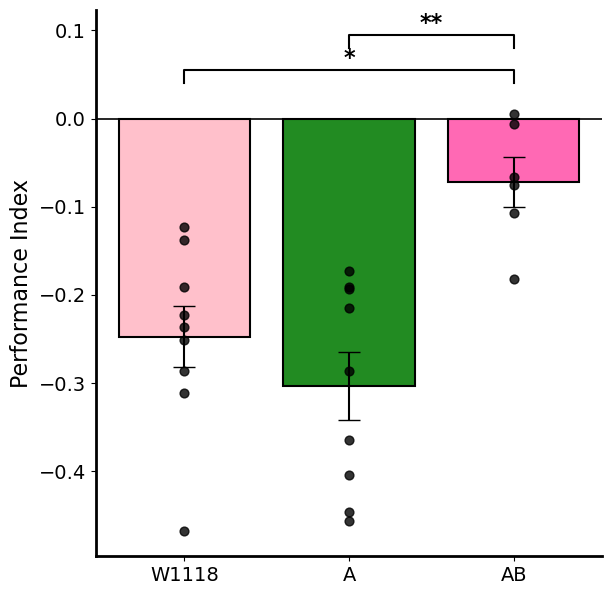

In [129]:
fast_plotter(["W1118","A","AB"], bar_color=["pink","forestgreen","hotpink"])

In [126]:
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Salary': [50000, 60000, 70000],
    'Department': ['HR', 'IT', 'Finance']
})
df.head()




,Name,Age,Salary,Department
0,Alice,25,50000,HR
1,Bob,30,60000,IT
2,Charlie,35,70000,Finance


[array([50000, 60000, 70000]), array([25, 30, 35])]

---------- STATS ----------
Salary
  W statistic = 1.0000
  p-value     = 1.0000
  → Data look approximately normal

Age
  W statistic = 1.0000
  p-value     = 1.0000
  → Data look approximately normal

Brown-Forsythe test
Statistic = 3.9960
p-value   = 0.1162
→ Variances are not significantly different

One-way ANOVA
F statistic = 107.8920
p-value     = 0.0005
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.9643
Effect size interpretation: large
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2 meandiff p-adj    lower      upper    reject
----------------------------------------------------------
   Age Salary  59970.0 0.0005 43940.1847 75999.8153   True
----------------------------------------------------------
Salary vs Age
  Cohen's d = 8.4810
  Effect size: large

['pink', 'forestgreen']
group: Salary, mean: 60000.0, sem: 5773.502691896258
group: Age, mean: 30.0, sem: 2.88

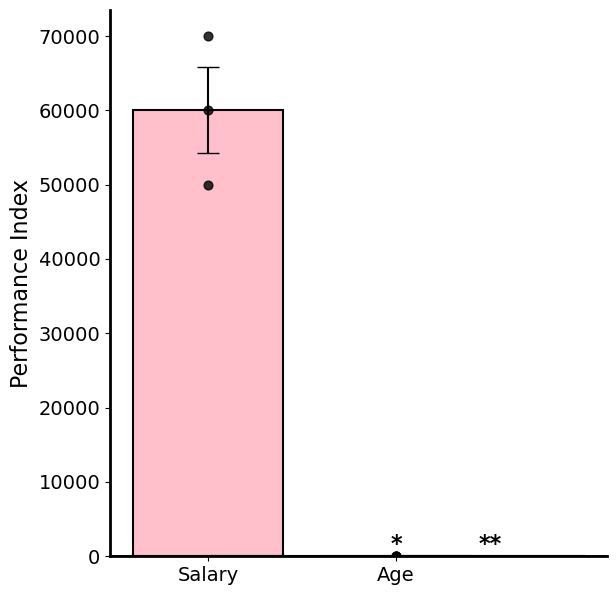

In [130]:
fast_plotter(["Salary","Age"], df = df,bar_color=["pink","forestgreen"])